In [36]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import math

In [37]:
# device
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [38]:
# variables
T = 1500 # timesteps
img_size = 28 # FashionMNIST
batch_size = 128
epochs = 20
lr = 1e-3
base_channels = 64 # base channels used for U-Net

In [39]:
# importing dataset

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x*2 - 1)    # Changing range from (0, 1) to (-1, 1)
])

train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

In [40]:
# Forward Process Parameters
import torch

class LinearNoiseScheduler:
    def __init__(self, num_timesteps, beta_start, beta_end):
        self.num_timesteps = num_timesteps
        self.beta_start = beta_start
        self.beta_end = beta_end

        # All these tensors have dimension --> [1000] if num_timesteps = 1000
        self.betas = torch.linspace(beta_start, beta_end, num_timesteps)
        self.alphas = 1. - self.betas
        self.alpha_bars = torch.cumprod(self.alphas, dim=0)
        self.sqrt_alpha_bars = torch.sqrt(self.alpha_bars)
        self.sqrt_one_minus_alpha_bars = torch.sqrt(1. - self.alpha_bars)

    def add_noise(self, x_0, noise, t):
        # sqrt_alpha_bars[t] has shape [batch_size] and we need to multiply it with [batch_size, 1, 28, 28] image.
        # for broadcasting to work correctly, we are adding dimensions to make it [batch_size, 1, 1, 1]
        sqrt_alpha_bars = self.sqrt_alpha_bars[t].reshape([-1, 1, 1, 1])   # Bx1x1x1
        sqrt_one_minus_alpha_bars = self.sqrt_one_minus_alpha_bars[t].reshape([-1, 1, 1, 1])   # Bx1x1x1

        # the direct formula to get x_t from x_0
        return sqrt_alpha_bars*x_0 + sqrt_one_minus_alpha_bars*noise

torch.Size([6, 1, 28, 28])
torch.Size([1, 28, 28])


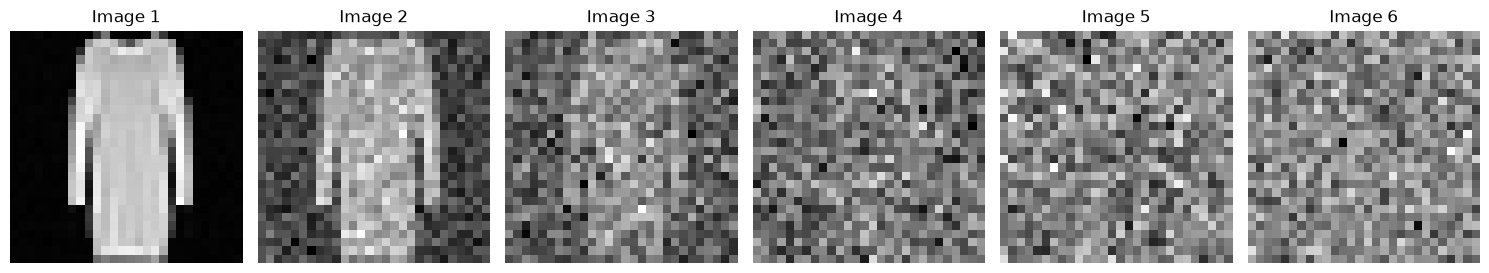

In [41]:
# testing add_noise on image from dataset
train_img, train_label = next(iter(train_loader))
train_img.shape, train_label.shape

test_img = train_img[0]
test_img_batched = torch.stack([test_img for _ in range(6)], dim=0)
print(test_img_batched.shape)
noise = torch.randn_like(test_img_batched)
t = [0, 100, 250, 500, 750, 999]

lns = LinearNoiseScheduler(1000, 1e-4, 0.02)
out_imgs = lns.add_noise(test_img_batched, noise=noise, t=t)
out_imgs = (out_imgs + 1)/2
print(out_imgs[1].shape)

fig, axes = plt.subplots(nrows=1, ncols=6, figsize=(15, 3))
for i in range(6):
    img = out_imgs[i].squeeze()
    img_numpy = img.cpu().numpy()

    axes[i].imshow(img_numpy, cmap="gray")
    axes[i].set_title(f"Image {i+1}")
    axes[i].axis("off") # Hide the grid and the pixel coordinates
plt.tight_layout()
plt.show()

In [42]:
import torch
time_steps = torch.randint(1, 1000, (128,))
frequencies = 1 / (10000 ** torch.arange(start=0, end=128//2, device=time_steps.device) / (128 // 2))
args = time_steps.unsqueeze(1) * frequencies.unsqueeze(0)
args.shape
sin_emb = torch.sin(args)
cos_emb = torch.cos(args)
emb = torch.stack((sin_emb, cos_emb), dim=2).reshape((time_steps.shape[0], -1))
print(emb.shape)

torch.Size([128, 128])


In [43]:
t1 = torch.tensor([10, 20, 30])
t2 = torch.tensor([1, 2, 3])

# combine - 
torch.stack((t1, t2), dim=1).reshape(-1)

tensor([10,  1, 20,  2, 30,  3])

In [ ]:
def sinusoidal_time_embedding(time_steps, t_emb_dim):
        """
            The even odd rule is for the dimension index i and not the timestep t.
            for each timestep t, we calculate the sin and cos in alternate manner
            pos 0 gets sin, pos 1 gets cos, pos 2 gets sin, pos 3 gets cos ... 
            the formula is - sin(t / 10000^(2i/d_model))
            Inputs:
                time_steps: Batched integer timesteps for images of shape [B,]
                t_emb_dim: The dimension of generated embeddings
            Outputs:
                emb: batched embedding for input timesteps, has shape [B, t_emb_dim]
        """
        # Since the argument inside the sin or cos function --> (t / 10000^(2i/d_model))
        # is basically just (t * frequency). We already have t so we need to calculate frequency part that depends on i.
        frequencies = 1 / (10000 ** (torch.arange(start=0, end=t_emb_dim//2, device=time_steps.device) / (t_emb_dim // 2)))   # Shape [t_emb_dim/2, ]

        # Now we multiply the frequencies with time_steps t. [B, ] x [t_emb_dim/2, ]
        args = time_steps.unsqueeze(1) * frequencies.unsqueeze(0)

        # Now applying sin and cos
        sin_emb = torch.sin(args)
        cos_emb = torch.cos(args)

        # Now need to join these in alternating manner (sin cos sin cos ...)
        emb = torch.stack((sin_emb, cos_emb), dim=2).reshape((time_steps.shape[0], -1))

        return emb

In [60]:
import torch
import torch.nn as nn

class ResBlock(nn.Module):

    def __init__(self, in_channels, out_channels, t_emb_dim=128):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.t_emb_dim = t_emb_dim
        
        self.act = nn.SiLU()
        
        # To map sinusoidal time embedding to out_channels
        self.lin = nn.Linear(self.t_emb_dim, self.out_channels)
        # Define First Conv Group
        self.norm1 = nn.GroupNorm(8, self.in_channels)
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=1, padding=1)
        # Define Second Conv Group
        self.norm2 = nn.GroupNorm(8, self.out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1)
        # For shortcut connection
        if in_channels != out_channels:
            self.linearProj = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=1, padding=0)
        else:
            self.linearProj = nn.Identity()

    def forward(self, x, time_emb):
        time_emb = self.lin(self.act(time_emb))
        x1 = self.conv1(self.act(self.norm1(x)))   # First conv step complete
        x1 = x1 + time_emb[..., None, None]        # Time embedding injection complete
        x2 = self.conv2(self.act(self.norm2(x1)))  # Second conv step complete
        x2 = x2 + self.linearProj(x)               # Shortcut connection complete
        return self.act(x2)



In [61]:
# testing 
time_steps = torch.randint(1, 1500, (batch_size, ))
time_emb = sinusoidal_time_embedding(time_steps, 128)
fake_imgs = torch.randn((batch_size, base_channels, 28, 28))
res1 = ResBlock(base_channels, 128)
output = res1(fake_imgs, time_emb)
output.shape

torch.Size([128, 128, 28, 28])

In [62]:
# The UNet Class
class UNet(nn.Module):

    def __init__(self, in_channels, base_channels, time_emb_dim):
        
        super().__init__()
        
        self.in_channels = in_channels
        self.base_channels = base_channels
        self.time_emb_dim = time_emb_dim
        self.channel_prog = [128, 256]

        # Define the stem
        self.stem = nn.Conv2d(self.in_channels, self.base_channels, kernel_size=3, stride=1, padding=1)
        
        # Define the encoder blocks
        self.downsample = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)  # Stride 2, reduces dimensions in half
        self.res1_e1 = ResBlock(self.base_channels, self.channel_prog[0])
        self.res2_e1 = ResBlock(self.channel_prog[0], self.channel_prog[0])
        self.res1_e2 = ResBlock(self.channel_prog[0], self.channel_prog[1])
        self.res2_e2 = ResBlock(self.channel_prog[1], self.channel_prog[1])

        # Define the bottleneck blocks
        self.res1_b = ResBlock(self.channel_prog[1], self.channel_prog[1])
        self.res2_b = ResBlock(self.channel_prog[1], self.channel_prog[1])

        # Define the decoder blocks
        self.upsample = nn.Upsample(scale_factor = 2, mode="nearest")   # Since we want to increase 2x height and 2x width
        self.res2_d2 = ResBlock(self.channel_prog[1]*2, self.channel_prog[1])
        self.res1_d2 = ResBlock(self.channel_prog[1], self.channel_prog[0])
        self.res2_d1 = ResBlock(self.channel_prog[0]*2, self.channel_prog[0])
        self.res1_d1 = ResBlock(self.channel_prog[0], self.base_channels)

        # Final Conv to convert from base_channels to single channel
        self.linearOut = nn.Conv2d(base_channels, 1, kernel_size=1, stride=1, padding=0)

    def forward(self, x, time_steps):

        # Calculate time embeddings
        time_emb = sinusoidal_time_embedding(time_steps, self.time_emb_dim)

        skip_features = []
        # [B, 1, 28, 28] -> [B, base, 28, 28] -> [B, 128, 28, 28] -> [B, 128, 28, 28]
        e = self.res2_e1(self.res1_e1(self.stem(x), time_emb), time_emb)
        skip_features.append(e)    # Saved e1 -> torch.Size([B, 128, 28, 28])
        e = self.downsample(e)    # [B, 128, 28, 28] -> [B, 128, 14, 14]
        # [B, 128, 14, 14] -> [B, 256, 14, 14] -> [B, 256, 14, 14]
        e = self.res2_e2(self.res1_e2(e, time_emb), time_emb)
        skip_features.append(e)    # Saved e2 -> torch.Size([B, 256, 14, 14])
        e = self.downsample(e)    # [B, 256, 14, 14] -> [B, 256, 7, 7]

        bottleneck = self.upsample(self.res2_b(self.res1_b(e, time_emb), time_emb))   # [B, 256, 7, 7] -> [B, 256, 14, 14]

        # Skip connection 1
        d = torch.concat((bottleneck, skip_features[1]), dim=1)    # [B, 256, 14, 14] + [B, 256, 14, 14] = [B, 512, 14, 14]
        
        # [B, 512, 14, 14] -> [B, 256, 14, 14] -> [B, 128, 14, 14] -> [B, 128, 28, 28]
        d = self.upsample(self.res1_d2(self.res2_d2(d, time_emb), time_emb))
        
        # Skip connection 2
        d = torch.concat((d, skip_features[0]), dim=1)  # [B, 128, 28, 28] + [B, 128, 28, 28] = [B, 256, 28, 28]

        # [B, 256, 28, 28] -> [B, 128, 28, 28] -> [B, base, 28, 28]
        d = self.res1_d1(self.res2_d1(d, time_emb), time_emb)

        return self.linearOut(d)

In [63]:
# testing encoder
unet = UNet(1, base_channels, 128)
fake_imgs = torch.randn((batch_size, 1, 28, 28))
time_steps = torch.randint(1, 1500, (batch_size, ))
out = unet(fake_imgs, time_steps)
print(out.shape)

torch.Size([128, 1, 28, 28])
